![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 1. Waveguides

Welcome to our Photonic Integrated Circuits Laboratory! Throughout the course, we will be using a Python package called [GDSFactory](https://gdsfactory.github.io/gdsfactory/index.html). This is an open-source tool, and is a great alternative to other commercial software like Synopsys Optodesigner, Luceda Photonics, or Lumerical/Interconnect. Since it runs on Python, you have two options for executing your laboratory tasks:

1. **Local installation on your own PC** (Recommended): Please note that we will not spend class time on installing the software. However, feel free to reach out if you need help with the installation.

2. **Cloud Workspace**: Alternatively, you can use a cloud-based solution if the Local installation does not work.

## 0. Imports

For this laboratory you will need the following libraries:

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength


## LO.1. Effective index of a waveguide

### 1.1. Materials

We need the refractive index of each material in the cross-section. There are different options to get this information, such as [RefractiveIndex.info](https://refractiveindex.info/) and the [Material Library from Tidy3D](https://docs.flexcompute.com/projects/tidy3d/en/v2.6.0/api/material_library.html#). Here we will load and check the characteristics from the most common materials used in fabrication of photonic circuits: **silicon (Si), silicon nitride (SiNx) and silicon dioxide (SiO2)**.

#### 1.1.1. Crystalline Silicon 

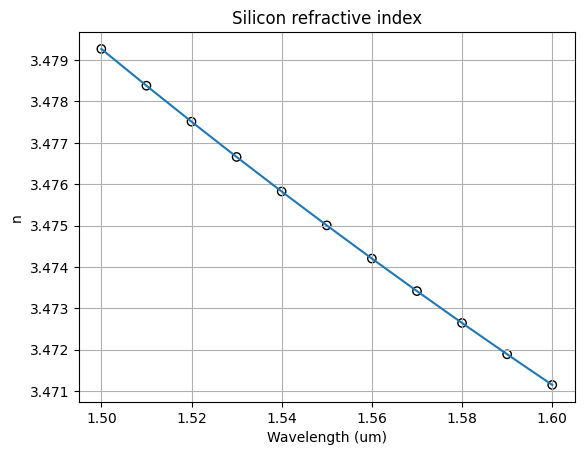

In [3]:
## Material model loaded
si_complex = td.material_library["cSi"]["Li1993_293K"].eps_model(f)
## Check the Tidy3D Docs for more information on the "Variant"

## Index at a particular wavelength
si_index , si_k = td.Medium.eps_complex_to_nk(si_complex)
plt.scatter(wavelength, si_index,edgecolors='k',facecolors='none')
plt.plot(wavelength,si_index)
plt.title("Silicon refractive index")
plt.xlabel("Wavelength (um)")
plt.ylabel("n")
plt.grid()

#### 1.1.2. Silicon Nitride

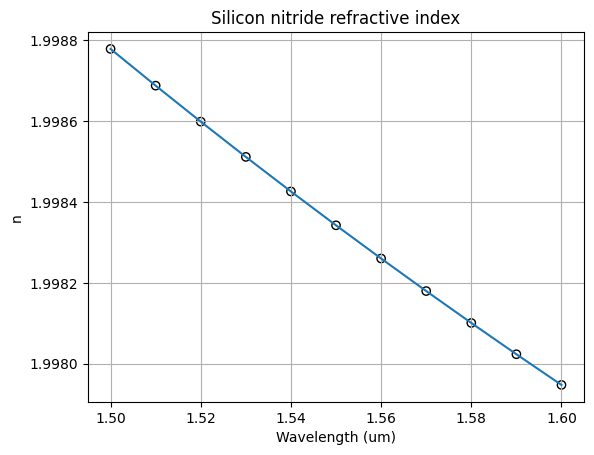

In [4]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
plt.scatter(wavelength,nitride_index,edgecolors='k',facecolors='none')
plt.plot(wavelength, nitride_index)
plt.title("Silicon nitride refractive index")
plt.xlabel("Wavelength (um)")
plt.ylabel("n")
plt.grid()


#### 1.1.3. Silicon Dioxide

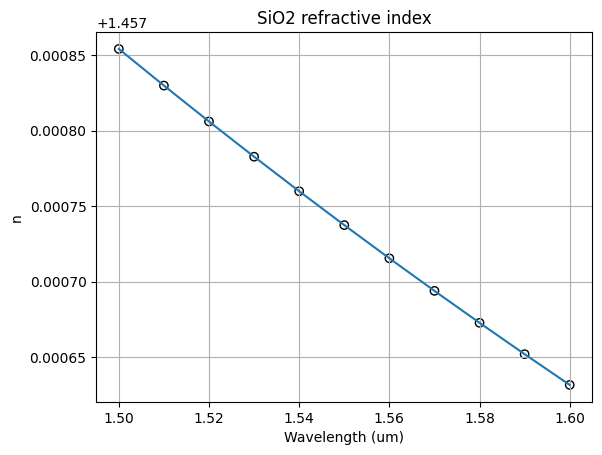

In [5]:
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)
plt.scatter(wavelength,box_index,edgecolors='k',facecolors='None')
plt.plot(wavelength, box_index)
plt.title("SiO2 refractive index")
plt.xlabel("Wavelength (um)")
plt.ylabel("n")
plt.grid()

### 1.2. Cross - Section Definition

In GDSFactory - Tidy3d modesolver we just have to use the [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. 
It implements the **deep (rib)** and **shallow (ridge)** waveguide variants. The following example corresponds to a **deep** waveguide for the **silicon nitride** fabrication proccess, this means that the **cladding** material is silicon dioxide and the **core** material is silicon nitride. The waveguide dimensions are 300 nm (height) and 1.2 um (width). We will check it's behavior at 1.55 um. 

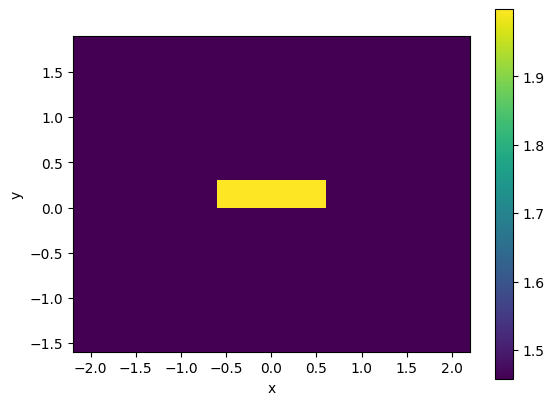

In [6]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=1.2, # Waveguide width
    core_thickness=300 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

deep_waveguide.plot_index()

### 1.3. Simulations

#### 1.3.1. Numerical results

We can find the effective index (n_eff), TE and TM fraction for each particular cross-section.

In [7]:
deep_waveguide.n_eff

2026-03-04 09:09:28.576 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cf92515ae4232c65.npz.


array([1.60524792+0.00010066j, 1.52829803+0.00017753j,
       1.45072999+0.00019228j, 1.43325817+0.00021838j])

In [8]:
deep_waveguide.fraction_te

array([0.99505426, 0.01004259, 0.96264794, 0.047651  ])

In [9]:
deep_waveguide.fraction_tm

array([0.00494574, 0.98995741, 0.03735206, 0.952349  ])

#### 1.3.4. Plots

Text(0.5, 1.0, 'Titulo')

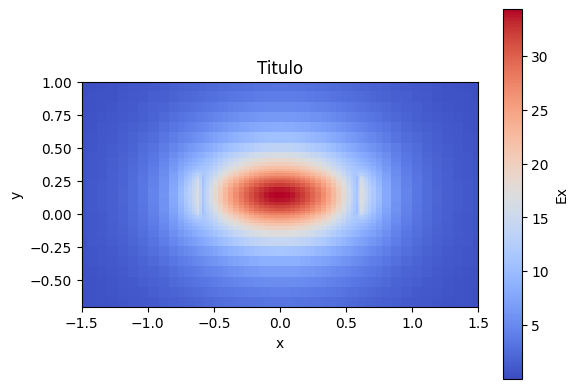

In [10]:
deep_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 
plt.title('Titulo') # You might need this later :) 

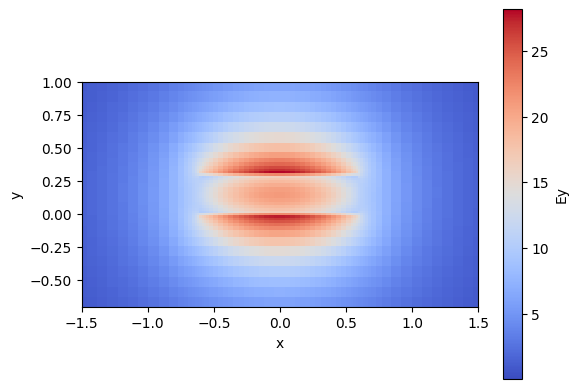

In [11]:
deep_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

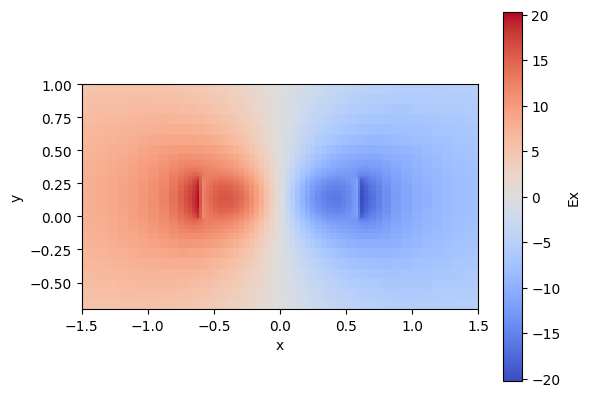

In [12]:
deep_waveguide.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

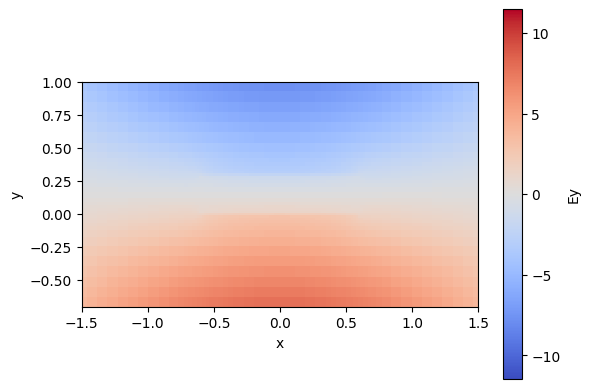

In [13]:
deep_waveguide.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

**Important** 
These results are derived from a numerical method used to solve the EM problem, so they must always be interpreted carefully to assess their accuracy. You must check, for instance, if the value of each index neff is higher than the refractive index of the cladding. 

## LO.2. Wavelength behavior

- Let's find the wavelength dependence of the effective index of the SiNx deep waveguide described in LO1. Change the wavelength used at the waveguide cross-section function, it could be a vector also. 

2026-03-04 09:09:30.127 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e70065e5b5dc42c3.npz.


2026-03-04 09:09:30.214 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cf0af488213d9e23.npz.


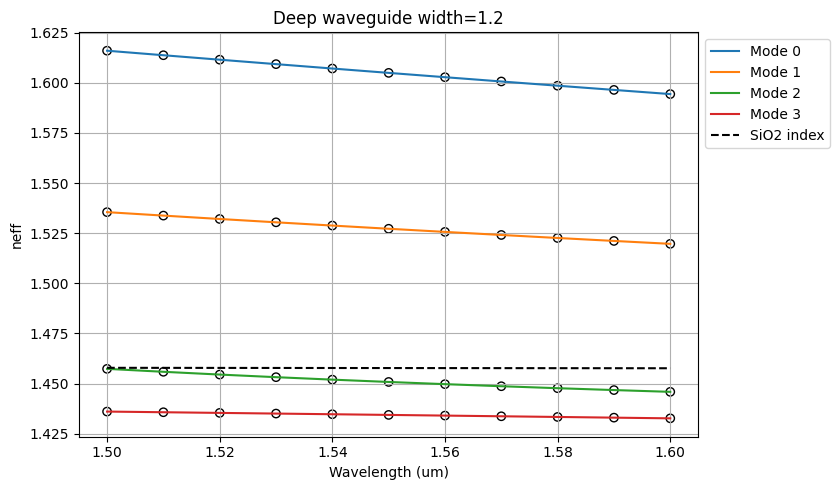

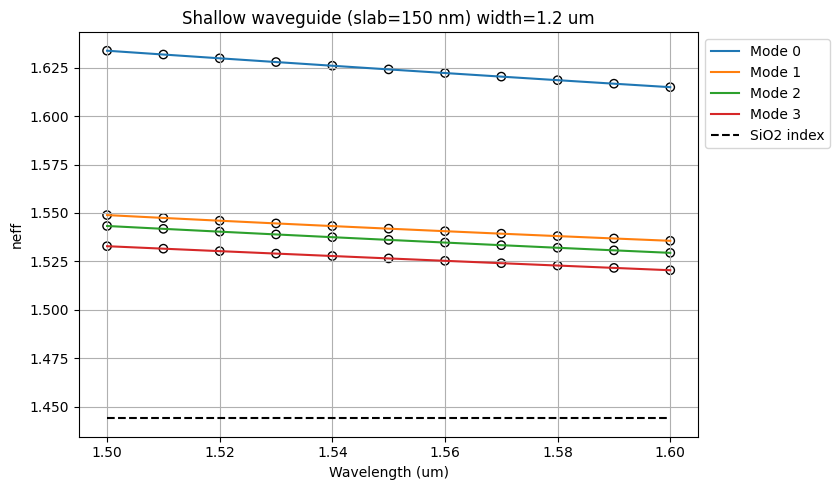

In [14]:
# The wavelength could be a vector also
nm = 1e-3
wavelength = np.linspace(1500, 1600, 11) * nm  # Student code here. Tip np.linspace()

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=1.2, 
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

res_neff = deep_waveguide.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te = deep_waveguide.fraction_te # Wavelength-dependent vector
res_tm =deep_waveguide.fraction_tm # Wavelength-dependent vector

plt.figure(figsize=(10, 5))
for k in range(res_neff.shape[1]):
    # It's necessary to 'access' each element on the array
    plt.scatter(wavelength, res_neff[:,k].real,edgecolors='k',facecolors='none',label = '__nolegend__')
    plt.plot(wavelength, res_neff[:,k].real,label=f'Mode {k}')
plt.title(f"Deep waveguide width={1.2}")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
# Common error: The box index variable was created in a previous cell. Check the dimensions match 
# with the newly created wavelength vector, or re-calculate the box index for the new one. 
plt.plot(wavelength, box_index,'k--', label='SiO2 index') 
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

nm= 1e-3
wavelength = np.linspace(1500, 1600, 11) * nm # 1.50–1.60 um

# --- Shallow waveguide (150 nm slab) ---
shallow_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=1.2,
    slab_thickness=150 * nm,      # <-- shallow etch: 150 nm slab
    core_material="sin",
    clad_material="sio2",
    core_thickness=300 * nm,      # total Si thickness (rib height is core_thickness - slab_thickness)
    num_modes=4,
    cache_path=".cache/",
    precision="double",
    max_grid_scaling=1.2,
    grid_resolution=20,
)

res_neff_sh = shallow_waveguide.n_eff
res_te_sh = shallow_waveguide.fraction_te
res_tm_sh = shallow_waveguide.fraction_tm

# --- Ensure box_index matches wavelength length (avoid dimension mismatch) ---
# If your notebook already defines box_index correctly for this wavelength, you can remove this block.
try:
    box_index = np.array([gt.materials.sio2.index(wl) for wl in wavelength], dtype=float)
except Exception:
    box_index = np.full_like(wavelength, 1.444, dtype=float)

# --- Plot neff vs wavelength ---
plt.figure(figsize=(10, 5))
for k in range(res_neff_sh.shape[1]):
    plt.scatter(
        wavelength,
        res_neff_sh[:, k].real,
        edgecolors="k",
        facecolors="none",
        label="__nolegend__",
    )
    plt.plot(wavelength, res_neff_sh[:, k].real, label=f"Mode {k}")

plt.title("Shallow waveguide (slab=150 nm) width=1.2 um")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid(True)

plt.plot(wavelength, box_index, "k--", label="SiO2 index")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


- Repeat the analysis for a **shallow**ly etched waveguide with a 150 nm slab heigth. 

## LO3 Sweep width 
- Perform a sweep of the **deep** waveguide width. Use the code provided in the following cell or program your own sweep. 

  0%|          | 0/11 [00:00<?, ?it/s]

2026-03-04 09:09:30.584 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e0f2a62752cad497.npz.


2026-03-04 09:09:30.591 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cad20f99025f789a.npz.
2026-03-04 09:09:30.595 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_575965d134f345c4.npz.
2026-03-04 09:09:30.600 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_3ca61e62fe85ccf2.npz.
2026-03-04 09:09:30.603 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_8b617c8aef408673.npz.
2026-03-04 09:09:30.608 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cd84020834745298.npz.
2026-03-04 09:09:30.615 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_df7667b1ace5cc7e.npz.
2026-03-04 09:09:30.621 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a4e198a34f8f1987.npz.
2026-03-04 09:09:30.630 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1cba93ec3f707c97.npz.


  0%|          | 0/11 [00:00<?, ?it/s]

2026-03-04 09:09:30.666 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e0f2a62752cad497.npz.
2026-03-04 09:09:30.670 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cad20f99025f789a.npz.
2026-03-04 09:09:30.674 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_575965d134f345c4.npz.
2026-03-04 09:09:30.681 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_3ca61e62fe85ccf2.npz.
2026-03-04 09:09:30.684 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_8b617c8aef408673.npz.
2026-03-04 09:09:30.687 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cd84020834745298.npz.
2026-03-04 09:09:30.693 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_df7667b1ace5cc7e.npz.
2026-03-04 09:09:30.696 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a4e198a34f8f1987.npz.


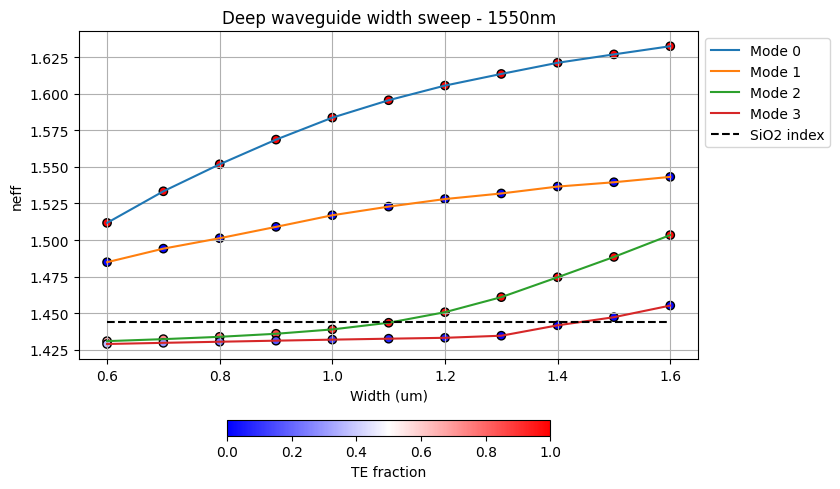

In [15]:
nm = 1e-3 
wavelength = 1550 * nm # Student code here

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=1.2,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    slab_thickness=0 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

w = np.linspace(0.6, 1.6, 11) # Student code here

sweep_neff = gt.modes.sweep_n_eff(deep_waveguide, 
                             core_width=w)

sweep_tefraction = gt.modes.sweep_fraction_te(deep_waveguide,
                                              core_width=w)

plt.figure(figsize=(10, 5))
for k in range(sweep_neff.shape[1]):
    plt.scatter(w, sweep_neff[:,k].real,edgecolors='k',c=sweep_tefraction.sel(mode_index=k),vmin=0, vmax=1,label = '__nolegend__',cmap='bwr')
    plt.plot(w, sweep_neff[:,k].real,label=f'Mode {k}')

plt.title("Deep waveguide width sweep - 1550nm")
plt.xlabel("Width (um)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w), xmax=np.max(w), colors='k', linestyles='dashed',label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.colorbar(orientation='horizontal',fraction=0.04).set_label("TE fraction")

## LO.4. Waveguide compact model

A compact model of an integrated photonic waveguide is a reduced-order mathematical model that describes the waveguide’s optical behavior—such as phase propagation, loss, and dispersion, using analytical or semi-analytical equations. Consider: 

Consider: 

The transfer function for propagation in a waveguide:

$$
H(\lambda)
= e^{-j\,\gamma(\lambda)\,z}
= e^{-j\,\mathrm{Re}\{\gamma(\lambda)\}\,z}\,
  e^{\mathrm{Im}\{\gamma(\lambda)\}\,z}.
$$

Where 

$$
\beta(\lambda) = \mathrm{Re}\{\gamma(\lambda)\}\,z
= \frac{2\pi}{\lambda}\,n_\mathrm{eff}(\lambda).
$$

Let's model the waveguide's effective index wavelength variation using a second order polynomial:

$$
n_\mathrm{eff}(\lambda)
= n_{1} + n_{2}\,(\lambda-\lambda_{0}) + n_{3}\,(\lambda-\lambda_{0})^{2}
$$

Where 

1. 
$$
n_\mathrm{eff}(\lambda_0) = n_1
$$
2. 
$$
n_g(\lambda_0) = n_1 - n_2\,\lambda_0
$$
3. 
$$
D = -\frac{2\,\lambda_0\,n_3}{c}\;\;[\mathrm{s}^2/\mathrm{m}]
$$

- Find the values for n, ng and D of the following waveguides: 
    - Deep waveguide, height = 300nm, width = 1.2um 
    - Shallow waveguide, core height = 300nm, slab height = 150 nm, width = 1.2um 

**TIP**. Use the Lab0.1.Modesolver results (neff vs lambda) as starting point. Fit the results using a second order polynomial (with the lambda_0 shift) and relate the fit results to n_g and D values.

2026-03-11 09:50:32.964 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e70065e5b5dc42c3.npz.


Deep Waveguide (TE0): n1=1.604917, n2=-0.216177, n3=0.097355
Deep Waveguide (TM0): n1=1.527189, n2=-0.157959, n3=0.153832
Deep Waveguide (TE0): ng=1.939991, D=-1.007e-03 s^2/m
Deep Waveguide (TM0): ng=1.772025, D=-1.591e-03 s^2/m


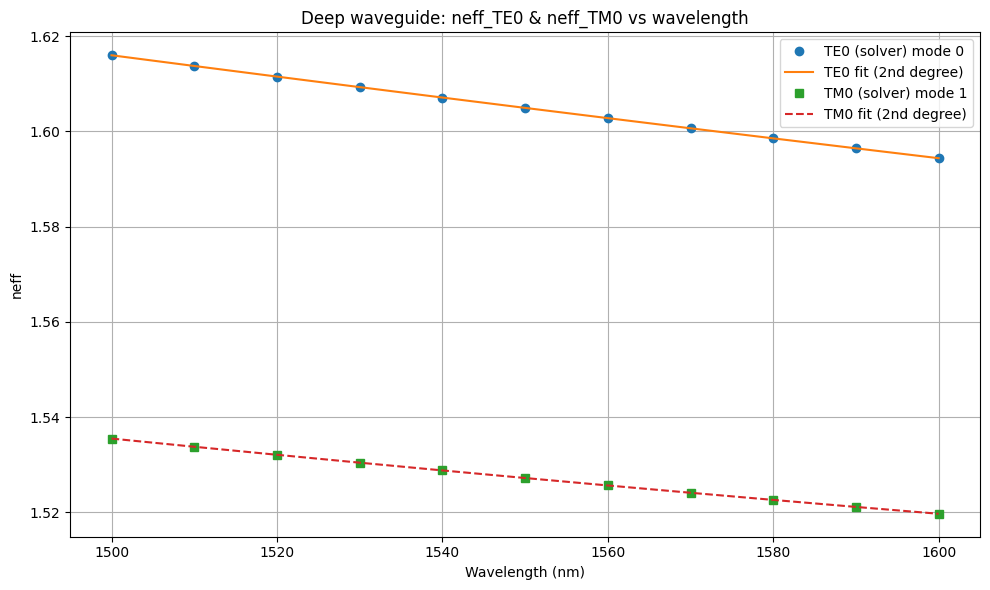

2026-03-11 09:50:33.298 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_92c6e82401e4cdd2.npz.
Shallow Waveguide (TE0): n1=1.619511, n2=-0.187449, n3=0.097619
Shallow Waveguide (TM0): n1=1.538647, n2=-0.140958, n3=0.159652
Shallow Waveguide (TE0): ng=1.910057, D=-1.009e-03 s^2/m
Shallow Waveguide (TM0): ng=1.757132, D=-1.651e-03 s^2/m


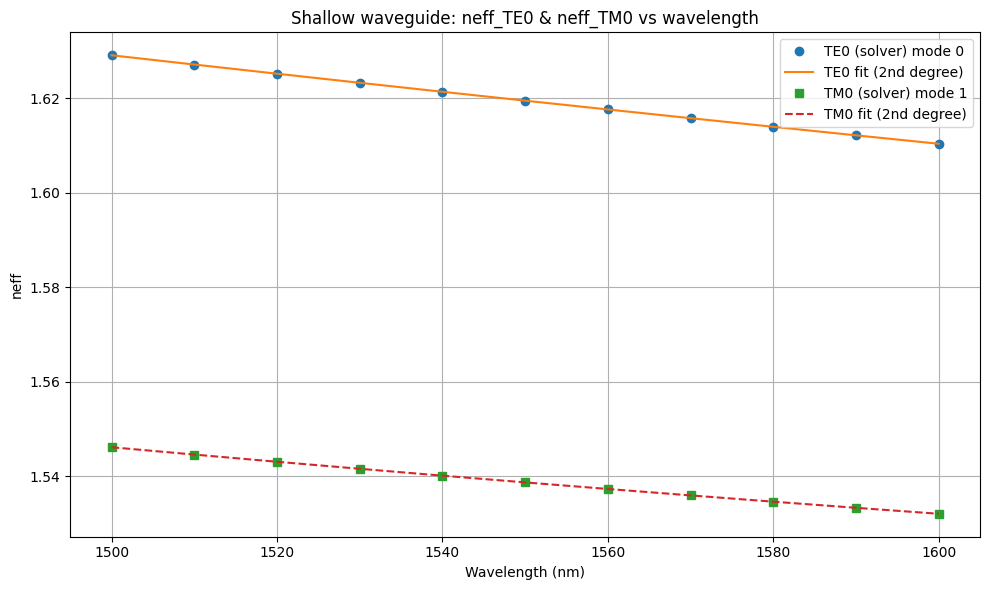

In [12]:
# STUDENT! Put your code here.

nm = 1e-3

# Sweep 1.50 – 1.60 um
wavelength = np.linspace(1500, 1600, 11) * nm
lambda0 = 1550 * nm
x = wavelength - lambda0

# Deep waveguide
deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=1.2,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    slab_thickness=0 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20,
)

# Extraer datos (solo una vez)
deep_neff = np.array(deep_waveguide.n_eff)
deep_fte  = np.array(deep_waveguide.fraction_te)
deep_ftm  = np.array(deep_waveguide.fraction_tm)

# Calcular automáticamente TE0 y TM0 
TE0_idx = int(np.argmax(deep_fte))
TM0_idx = int(np.argmax(deep_ftm))

neff_TE0 = deep_neff[:, TE0_idx].real
neff_TM0 = deep_neff[:, TM0_idx].real

# Ajuste polinomial 2º grado
coef_TE0 = np.polyfit(x, neff_TE0, 2)
coef_TM0 = np.polyfit(x, neff_TM0, 2)

fit_TE0 = np.polyval(coef_TE0, x)
fit_TM0 = np.polyval(coef_TM0, x)


n3_TE0, n2_TE0, n1_TE0 = coef_TE0
n3_TM0, n2_TM0, n1_TM0 = coef_TM0

print(f"Deep Waveguide (TE0): n1={n1_TE0:.6f}, n2={n2_TE0:.6f}, n3={n3_TE0:.6f}")
print(f"Deep Waveguide (TM0): n1={n1_TM0:.6f}, n2={n2_TM0:.6f}, n3={n3_TM0:.6f}")

c = 299792458
um_to_m = 1e-6

ng_TE0 = n1_TE0 - n2_TE0 * lambda0
ng_TM0 = n1_TM0 - n2_TM0 * lambda0

D_TE0 = -(2 * (lambda0 * um_to_m) * (n3_TE0 / (um_to_m**2))) / c
D_TM0 = -(2 * (lambda0 * um_to_m) * (n3_TM0 / (um_to_m**2))) / c

print(f"Deep Waveguide (TE0): ng={ng_TE0:.6f}, D={D_TE0:.3e} s^2/m")
print(f"Deep Waveguide (TM0): ng={ng_TM0:.6f}, D={D_TM0:.3e} s^2/m")



# ----------- Gráfica única -------------
plt.figure(figsize=(10, 6))

plt.plot(wavelength / nm, neff_TE0, "o", label=f"TE0 (solver) mode {TE0_idx}")
plt.plot(wavelength / nm, fit_TE0, "-", label="TE0 fit (2nd degree)")

plt.plot(wavelength / nm, neff_TM0, "s", label=f"TM0 (solver) mode {TM0_idx}")
plt.plot(wavelength / nm, fit_TM0, "--", label="TM0 fit (2nd degree)")

plt.title("Deep waveguide: neff_TE0 & neff_TM0 vs wavelength")
plt.xlabel("Wavelength (nm)")
plt.ylabel("neff")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Shallow waveguide (slab=150nm)
shallow_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=1.2,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    slab_thickness=150 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.5,
    grid_resolution=20,
)

# Extraer datos (solo una vez)
shallow_neff = np.array(shallow_waveguide.n_eff)
shallow_fte  = np.array(shallow_waveguide.fraction_te)
shallow_ftm  = np.array(shallow_waveguide.fraction_tm)

# Calcular automáticamente TE0 y TM0 (fte/ftm suelen ser 1D en tu caso)
TE0_idx = 0
TM0_idx = 1

neff_TE0 = shallow_neff[:, TE0_idx].real
neff_TM0 = shallow_neff[:, TM0_idx].real

# Ajuste polinomial 2º grado
coef_TE0 = np.polyfit(x, neff_TE0, 2)
coef_TM0 = np.polyfit(x, neff_TM0, 2)


fit_TE0 = np.polyval(coef_TE0, x)
fit_TM0 = np.polyval(coef_TM0, x)
# Los coeficientes son: [n3, n2, n1] 
n3_shallow_TE0, n2_shallow_TE0, n1_shallow_TE0 = coef_TE0
n3_shallow_TM0, n2_shallow_TM0, n1_shallow_TM0 = coef_TM0

print(f"Shallow Waveguide (TE0): n1={n1_shallow_TE0:.6f}, n2={n2_shallow_TE0:.6f}, n3={n3_shallow_TE0:.6f}")
print(f"Shallow Waveguide (TM0): n1={n1_shallow_TM0:.6f}, n2={n2_shallow_TM0:.6f}, n3={n3_shallow_TM0:.6f}")
ng_shallow_TE0 = n1_shallow_TE0 - n2_shallow_TE0 * lambda0
ng_shallow_TM0 = n1_shallow_TM0 - n2_shallow_TM0 * lambda0

D_shallow_TE0 = -(2 * (lambda0 * um_to_m) * (n3_shallow_TE0 / (um_to_m**2))) / c
D_shallow_TM0 = -(2 * (lambda0 * um_to_m) * (n3_shallow_TM0 / (um_to_m**2))) / c

print(f"Shallow Waveguide (TE0): ng={ng_shallow_TE0:.6f}, D={D_shallow_TE0:.3e} s^2/m")
print(f"Shallow Waveguide (TM0): ng={ng_shallow_TM0:.6f}, D={D_shallow_TM0:.3e} s^2/m")


# ----------- Gráfica única -------------
plt.figure(figsize=(10, 6))

plt.plot(wavelength / nm, neff_TE0, "o", label=f"TE0 (solver) mode {TE0_idx}")
plt.plot(wavelength / nm, fit_TE0, "-", label="TE0 fit (2nd degree)")

plt.plot(wavelength / nm, neff_TM0, "s", label=f"TM0 (solver) mode {TM0_idx}")
plt.plot(wavelength / nm, fit_TM0, "--", label="TM0 fit (2nd degree)")

plt.title("Shallow waveguide: neff_TE0 & neff_TM0 vs wavelength")
plt.xlabel("Wavelength (nm)")
plt.ylabel("neff")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

## LO.5. Bend waveguide radius vs. loss – deep

The bend loss has three primary contributions:

1. Mode-mismatch loss
2. Radiation loss
3. Propagation loss

2026-03-04 09:40:46.946 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1592dba1d8e935a8.npz.


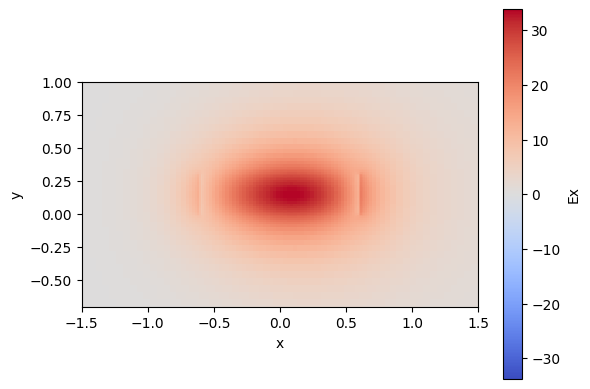

In [35]:
bend_1550 = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=1.2,
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30, 
    bend_radius=20, # Bend radius
)

bend_1550.plot_field(field_name="Ex", 
                     mode_index=0, # Field to be plotted
                     value='real', # Real - abs - imag
                     cmap='coolwarm',
                     xlim=(-1.5, 1.5), # Set the x and y limits
                     ylim=(-0.7, 1)) 

### Mode-mismatch loss

Bend waveguide mode differs slightly from the straight waveguide mode, wich yield into mode-convertion losses. We can calculate this factor with as the overlap of the latter two modes. 

This is already implemented on GDSfactory library: 

  0%|          | 0/21 [00:00<?, ?it/s]

/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

Text(0, 0.5, 'Mismatch (dB)')

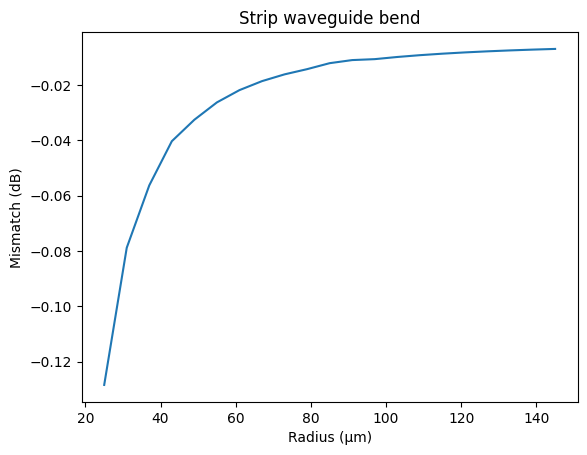

In [36]:
radii = np.arange(25, 150,6)

mismatch = gt.modes.sweep_bend_mismatch(bend_1550, radii)

plt.plot(radii, 10 * np.log10(mismatch))
plt.title("Strip waveguide bend")
plt.xlabel("Radius (μm)")
plt.ylabel("Mismatch (dB)")

### Propagation loss

Consider the equivalent linear length of the quarter-circle bend. Light will attenuate following a trend quantified with the experimentally measured parameter $$\alpha [\mathrm{dB}/\mathrm{cm}]$$. It depends on the fabrication process mainly. We will add this loss (in dBs) to the mode-mismatch loss to calculate the total loss per bend. 

*We are not considering the radiation losses, mainly because is not easy to implement a quick simulation for this parameter. Under certain conditions, the main loss sources are the ones considered in this example


2026-03-04 09:44:44.447 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_13f241434025c7df.npz.
2026-03-04 09:44:44.451 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_5e0454dcd82baf96.npz.
2026-03-04 09:44:44.460 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2ade7bb4dc161d0d.npz.
2026-03-04 09:44:44.469 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_fb8586aea6efaaf2.npz.


/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

2026-03-04 09:44:47.183 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_46b38fd03ec1e3c2.npz.


/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

2026-03-04 09:44:51.657 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_d071ed820a602d56.npz.


...

/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

2026-03-04 09:45:42.987 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_0b4e49e6330f2f7b.npz.


/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

2026-03-04 09:45:47.347 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_fe9ca6f480f37ec0.npz.


/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


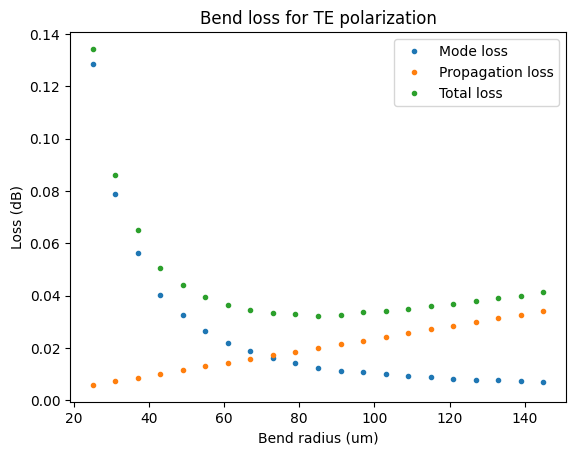

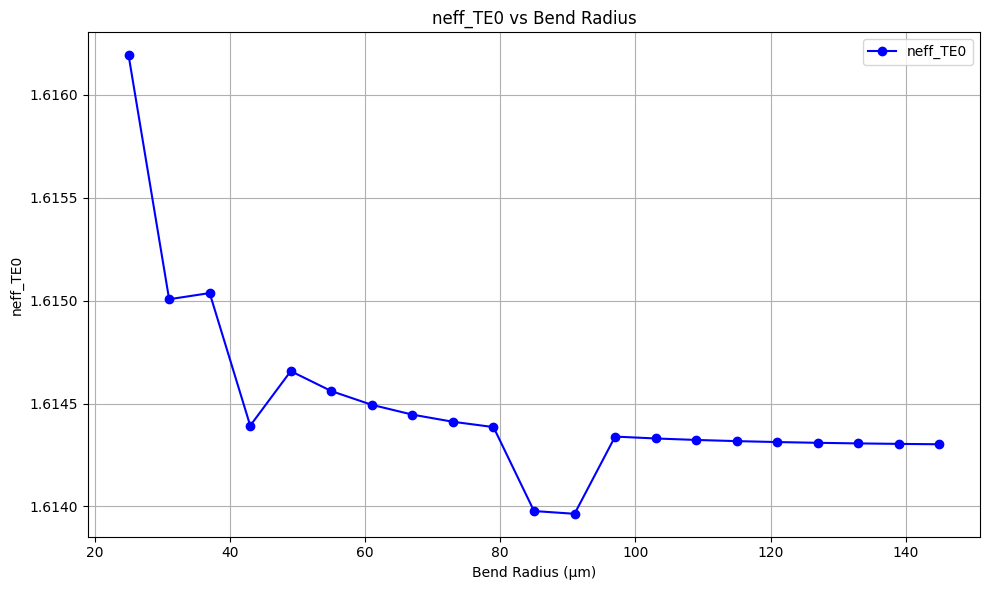

In [44]:
dB_cm = 1.5  # dB/cm Technology loss - 
length = 0.5 * np.pi * radii * 1e-6
propagation_loss = dB_cm * length * 1e2
propagation_loss

plt.title("Bend loss for TE polarization")
plt.plot(radii, -10 * np.log10(mismatch), ".", label="Mode loss")
plt.plot(radii, propagation_loss, ".", label="Propagation loss")
plt.plot(radii, propagation_loss-10 * np.log10(mismatch), ".", label="Total loss")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB)")
plt.legend()


neff_TE0_values = []

# Barrido sobre los radios de curvatura
for radius in radii:
    bend_1550 = gt.modes.Waveguide(
        wavelength=1550 * nm,
        core_width=1.2,
        slab_thickness=0.0,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300 * nm,
        num_modes=1,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.2,
        grid_resolution=30, 
        bend_radius=radius, # Bend radius
    )  
    res = bend_1550.n_eff
    #print(res.real)
    # neff_TE0 = res[:, 0].real
    neff_TE0_values.append(res)  

# Graficar neff_TE0 vs R (radio de curvatura)
plt.figure(figsize=(10, 6))
plt.plot(radii, neff_TE0_values, label="neff_TE0", marker='o', color='b')

plt.title("neff_TE0 vs Bend Radius")
plt.xlabel("Bend Radius (µm)")
plt.ylabel("neff_TE0")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

- Use the code provided in this section to calculate the safe radius for 1.2 um width deep waveguides at 1.5 um. Consider safe means less than 0.1 dB/90º

## EXTRA

All the past simulations were done considering as core material de Silicon Nitride (SiNx) and Silicon Dioxide (SiO2) as cladding material. Now, **simulate the Silicon-On-Insulator technology changing the core material to Silicon (Si)**. In this case, the dimensions will be 220 nm heigth and 500 nm width. 
1. Repeat the LO.2. wavelength behavior simulations, considering the updated materials and dimensions. 
2. Repeat the LO.3. width dependence analysis, now sweeping in a 300nm - 1um range. 
3. Find the safe radius for this technology. Consider sweeping the radius in a 5um to 30um range. 
4. **Compare the SiNx and SOI technologies** 

## Simulation with Silicon (Si)

1.1. Repeat the LO.2. wavelength behavior simulations, considering the updated materials and dimensions. 


/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

09:15:04 CET WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 1, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 2, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 3, mode index 3 does not    
             decay at the plane boundaries.                                     

...

             WARNING: Mode field at frequency index 8, mode index 3 does not    
             decay at the plane boundaries.                                     

09:15:05 CET WARNING: Mode field at frequency index 9, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 10, mode index 3 does not   
             decay at the plane boundaries.                                     

             WARNING: The group index was not computed. To calculate group      
             index, pass 'group_index_step = True' in the 'ModeSpec'.           

2026-03-11 09:15:05.295 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_38091c594b211d32.npz.


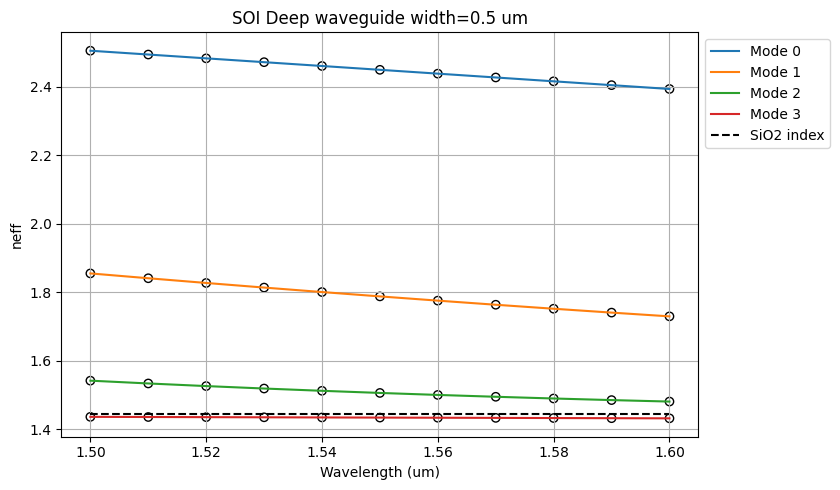

/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

09:15:24 CET WARNING: Mode field at frequency index 0, mode index 1 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 2 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 1, mode index 1 does not    
             decay at the plane boundaries.                                     

...

             WARNING: Mode field at frequency index 9, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 10, mode index 1 does not   
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 10, mode index 2 does not   
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 10, mode index 3 does not   
             decay at the plane boundaries.                                     

2026-03-11 09:15:27.025 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_6b460bacebf292ab.npz.


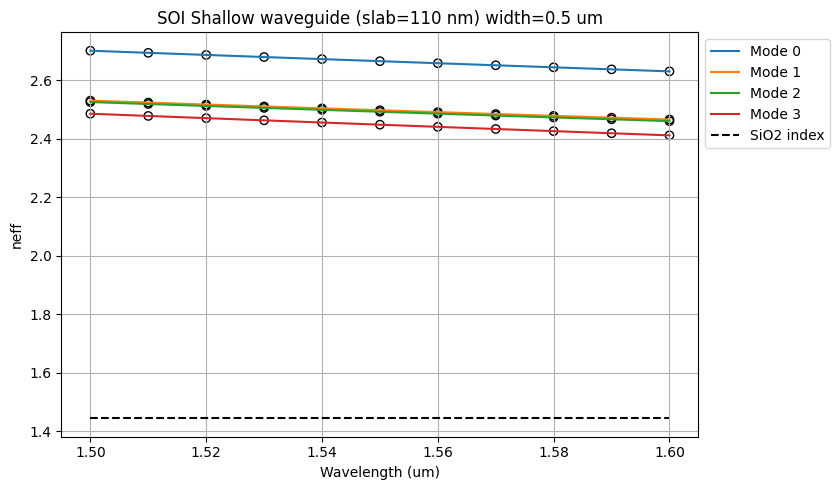

In [3]:
# The wavelength could be a vector also
nm = 1e-3
wavelength = np.linspace(1500, 1600, 11) * nm  # 1.50–1.60 um

# --- Deep waveguide SOI ---
deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=0.5,                # 500 nm
    slab_thickness=0.0,            # deep
    core_material='si',            # Silicon
    clad_material='sio2',
    core_thickness=220 * nm,       # 220 nm
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

res_neff = deep_waveguide.n_eff
res_te = deep_waveguide.fraction_te
res_tm = deep_waveguide.fraction_tm

# Recalcular box_index para evitar errores de dimensiones
try:
    box_index = np.array([gt.materials.sio2.index(wl) for wl in wavelength], dtype=float)
except Exception:
    box_index = np.full_like(wavelength, 1.444, dtype=float)

plt.figure(figsize=(10, 5))
for k in range(res_neff.shape[1]):
    plt.scatter(wavelength, res_neff[:,k].real, edgecolors='k', facecolors='none', label='__nolegend__')
    plt.plot(wavelength, res_neff[:,k].real, label=f'Mode {k}')

plt.title("SOI Deep waveguide width=0.5 um")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
plt.plot(wavelength, box_index, 'k--', label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

nm = 1e-3
wavelength = np.linspace(1500, 1600, 11) * nm  # 1.50–1.60 um

# --- Shallow waveguide SOI ---
shallow_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=0.5,                # 500 nm
    slab_thickness=150 * nm,       # shallow example
    core_material='si',            # Silicon
    clad_material='sio2',
    core_thickness=220 * nm,       # 220 nm
    num_modes=4,
    cache_path=".cache/",
    precision="double",
    max_grid_scaling=1.2,
    grid_resolution=20,
)

res_neff_sh = shallow_waveguide.n_eff
res_te_sh = shallow_waveguide.fraction_te
res_tm_sh = shallow_waveguide.fraction_tm

try:
    box_index = np.array([gt.materials.sio2.index(wl) for wl in wavelength], dtype=float)
except Exception:
    box_index = np.full_like(wavelength, 1.444, dtype=float)

plt.figure(figsize=(10, 5))
for k in range(res_neff_sh.shape[1]):
    plt.scatter(
        wavelength,
        res_neff_sh[:, k].real,
        edgecolors="k",
        facecolors="none",
        label="__nolegend__",
    )
    plt.plot(wavelength, res_neff_sh[:, k].real, label=f"Mode {k}")

plt.title("SOI Shallow waveguide (slab=110 nm) width=0.5 um")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid(True)
plt.plot(wavelength, box_index, "k--", label="SiO2 index")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


2. Repeat the LO.3. width dependence analysis, now sweeping in a 300nm - 1um range. 


  0%|          | 0/11 [00:00<?, ?it/s]

2026-03-11 09:29:53.720 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_58b0951888c2c7de.npz.


/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

09:29:56 CET WARNING: Mode field at frequency index 0, mode index 2 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

...

2026-03-11 09:30:14.124 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_775d34482dd5ca51.npz.


/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

2026-03-11 09:30:16.826 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_b6ad258a08cca064.npz.
2026-03-11 09:30:16.839 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_07b520dc17f68bb3.npz.


  0%|          | 0/11 [00:00<?, ?it/s]

2026-03-11 09:30:16.860 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_58b0951888c2c7de.npz.
2026-03-11 09:30:16.865 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c043cea1c22bbca0.npz.
2026-03-11 09:30:16.870 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_28434cde2556ce91.npz.
2026-03-11 09:30:16.875 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6263ab2d46d2c516.npz.
2026-03-11 09:30:16.878 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a0f601d80c3c89ef.npz.
2026-03-11 09:30:16.882 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_90c1b71feb516776.npz.
2026-03-11 09:30:16.885 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_5579fd98f4637b70.npz.
2026-03-11 09:30:16.890 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1f7136b702d27490.npz.


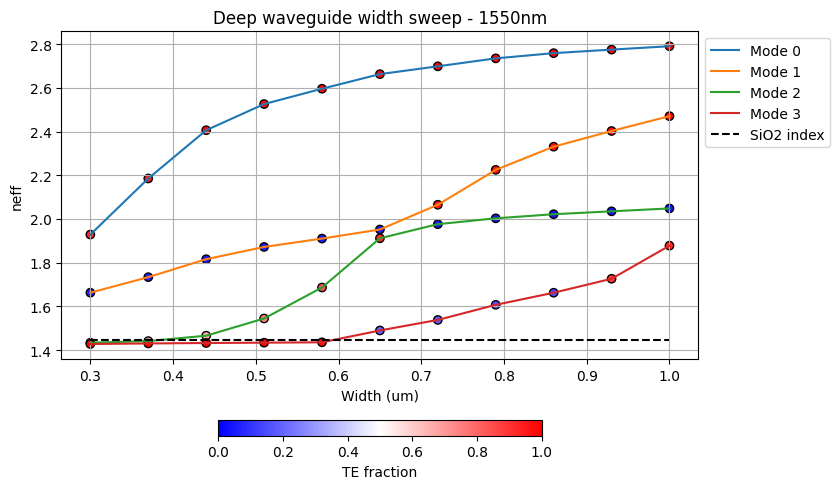

In [7]:
nm = 1e-3 
wavelength = 1550 * nm # Student code here

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=0.5,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    slab_thickness=0 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

w = np.linspace(0.3, 1.0, 11) # Student code here

sweep_neff = gt.modes.sweep_n_eff(deep_waveguide, 
                             core_width=w)

sweep_tefraction = gt.modes.sweep_fraction_te(deep_waveguide,
                                              core_width=w)

plt.figure(figsize=(10, 5))
for k in range(sweep_neff.shape[1]):
    plt.scatter(w, sweep_neff[:,k].real,edgecolors='k',c=sweep_tefraction.sel(mode_index=k),vmin=0, vmax=1,label = '__nolegend__',cmap='bwr')
    plt.plot(w, sweep_neff[:,k].real,label=f'Mode {k}')

plt.title("Deep waveguide width sweep - 1550nm")
plt.xlabel("Width (um)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w), xmax=np.max(w), colors='k', linestyles='dashed',label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.colorbar(orientation='horizontal',fraction=0.04).set_label("TE fraction")

3. Find the safe radius for this technology. Consider sweeping the radius in a 5um to 30um range.

  0%|          | 0/26 [00:00<?, ?it/s]

/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

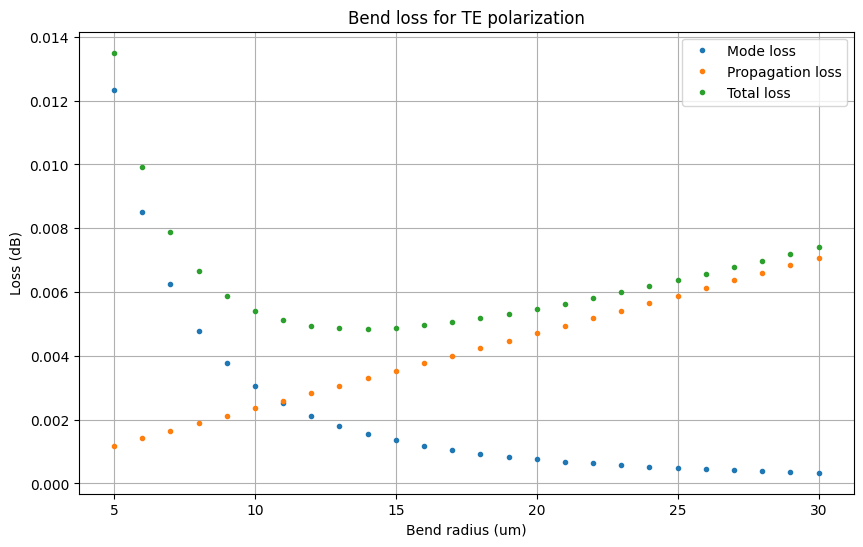

2026-03-11 09:42:33.764 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_dc3d1854e26bf6af.npz.
2026-03-11 09:42:33.771 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_d344e6140d01eea3.npz.
2026-03-11 09:42:33.776 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_65291ef102838d98.npz.
2026-03-11 09:42:33.782 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cda2e3f35b896149.npz.
2026-03-11 09:42:33.793 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_8b58e81eb79d9000.npz.
2026-03-11 09:42:33.799 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_190a435d611d6ac0.npz.
2026-03-11 09:42:33.807 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f03a087118e48c7c.npz.
2026-03-11 09:42:33.816 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_52082c0c4404efa2.npz.


/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/arnau/cifoin-lab1/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


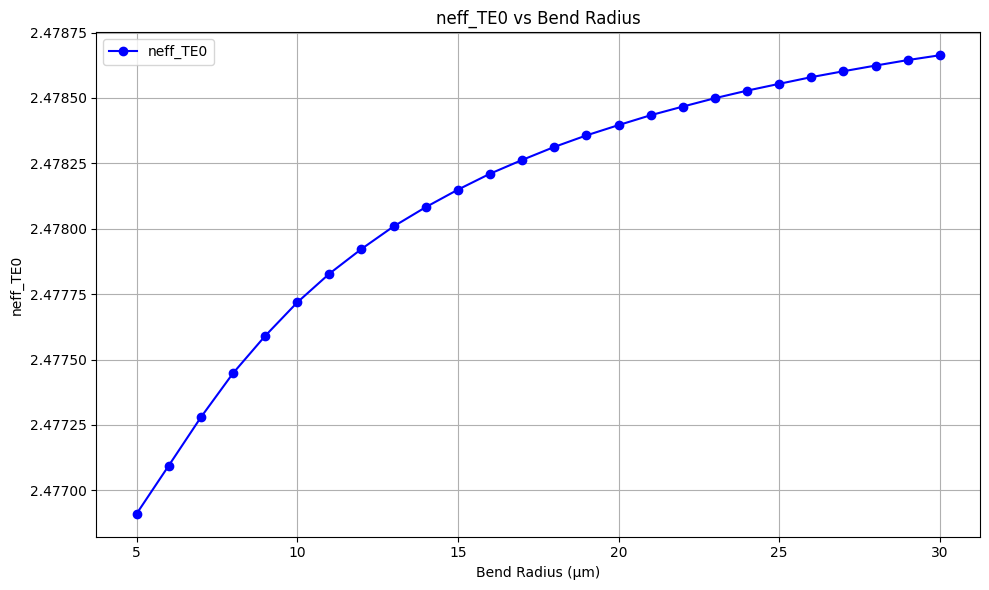

In [9]:
bend_1550 = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=0.5,
    slab_thickness=0.0,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30, 
    bend_radius=20,
)

radii = np.arange(5, 31, 1)

mismatch = gt.modes.sweep_bend_mismatch(bend_1550, radii)

dB_cm = 1.5
length = 0.5 * np.pi * radii * 1e-6
propagation_loss = dB_cm * length * 1e2

plt.figure(figsize=(10, 6))
plt.title("Bend loss for TE polarization")
plt.plot(radii, -10 * np.log10(mismatch), ".", label="Mode loss")
plt.plot(radii, propagation_loss, ".", label="Propagation loss")
plt.plot(radii, propagation_loss - 10 * np.log10(mismatch), ".", label="Total loss")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB)")
plt.legend()
plt.grid(True)
plt.show()


neff_TE0_values = []

for radius in radii:
    bend_1550 = gt.modes.Waveguide(
        wavelength=1550 * nm,
        core_width=0.5,
        slab_thickness=0.0,
        core_material='si',
        clad_material='sio2',
        core_thickness=220 * nm,
        num_modes=1,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.2,
        grid_resolution=30, 
        bend_radius=radius,
    )  
    res = bend_1550.n_eff
    neff_TE0_values.append(res)

plt.figure(figsize=(10, 6))
plt.plot(radii, neff_TE0_values, label="neff_TE0", marker='o', color='b')
plt.title("neff_TE0 vs Bend Radius")
plt.xlabel("Bend Radius (µm)")
plt.ylabel("neff_TE0")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Grading

LO.1. 1 Point <br> 
LO.2. 2 Points <br> 
LO.3. 1 Point <br> 
LO.4. 2 Points <br> 
LO.5. 1 Point <br> 
**Total 7 Points** <br>
Extra (Up to) 3 Points
